In [1]:
import os
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from pathlib import Path

THINGS_DIR = (r"C:\Users\Hp\.vscode\PROJECT 07"
              r"\classifier_main_pipeline\data"
              r"\things_eeg")

# ── Reload the wrongly shaped file and fix it ─────────────
wrong_train = np.load(
    os.path.join(THINGS_DIR,
                 'eeg_train_avg_all_subjects.npy')
)
wrong_test  = np.load(
    os.path.join(THINGS_DIR,
                 'eeg_test_avg_all_subjects.npy')
)

print(f"Loaded (wrong) train shape: {wrong_train.shape}")
print(f"Loaded (wrong) test shape:  {wrong_test.shape}")

# Figure out how many subjects got concatenated
n_train_images = 1654
n_test_images  = 200

n_subj_train = wrong_train.shape[0] // n_train_images
n_subj_test  = wrong_test.shape[0]  // n_test_images

print(f"\nDetected: {n_subj_train} subjects concatenated "
      f"in train file")
print(f"Detected: {n_subj_test} subjects concatenated "
      f"in test file")

# Reshape → (n_subjects, n_images, 17, 100)
# Then average over subjects axis=0
train_reshaped = wrong_train.reshape(
    n_subj_train, n_train_images,
    wrong_train.shape[1], wrong_train.shape[2]
)
test_reshaped  = wrong_test.reshape(
    n_subj_test, n_test_images,
    wrong_test.shape[1], wrong_test.shape[2]
)

print(f"\nReshaped:")
print(f"  Train: {train_reshaped.shape}")
print(f"  Test:  {test_reshaped.shape}")

# Average over subjects → cleaner signal
eeg_train = train_reshaped.mean(axis=0)  # (1654, 17, 100)
eeg_test  = test_reshaped.mean(axis=0)   # (200,  17, 100)

print(f"\n Fixed shapes:")
print(f"  Train: {eeg_train.shape}  ← correct")
print(f"  Test:  {eeg_test.shape}   ← correct")

# Overwrite with correct version
np.save(os.path.join(THINGS_DIR,
                      'eeg_train_avg_all_subjects.npy'),
        eeg_train)
np.save(os.path.join(THINGS_DIR,
                      'eeg_test_avg_all_subjects.npy'),
        eeg_test)

print("\n Saved corrected files")

Loaded (wrong) train shape: (1654, 17, 100)
Loaded (wrong) test shape:  (200, 17, 100)

Detected: 1 subjects concatenated in train file
Detected: 1 subjects concatenated in test file

Reshaped:
  Train: (1, 1654, 17, 100)
  Test:  (1, 200, 17, 100)

 Fixed shapes:
  Train: (1654, 17, 100)  ← correct
  Test:  (200, 17, 100)   ← correct

 Saved corrected files


In [2]:
!pip install -q huggingface_hub

In [3]:
# ── Create concept labels from EEG ordering ───────────────
import os
import numpy as np
from pathlib import Path

# THINGS-EEG data is already arranged as:
# Training: 1654 concepts
# Test:      200 concepts

train_concepts_path = os.path.join(
    THINGS_DIR,
    'train_concept_labels.npy'
)

test_concepts_path = os.path.join(
    THINGS_DIR,
    'test_concept_labels.npy'
)

# ── Load training EEG ─────────────────────────────────────

all_train_files = sorted(
    Path(THINGS_DIR).rglob(
        'preprocessed_eeg_training.npy'
    )
)

train_dict = np.load(
    str(all_train_files[0]),
    allow_pickle=True
).item()

train_eeg = train_dict[
    'preprocessed_eeg_data'
]

# ── Load test EEG ─────────────────────────────────────────

all_test_files = sorted(
    Path(THINGS_DIR).rglob(
        'preprocessed_eeg_test.npy'
    )
)

test_dict = np.load(
    str(all_test_files[0]),
    allow_pickle=True
).item()

test_eeg = test_dict[
    'preprocessed_eeg_data'
]

# ── Create labels preserving EEG order ────────────────────

train_concepts = np.arange(
    train_eeg.shape[0]
).astype(str)

test_concepts = np.arange(
    test_eeg.shape[0]
).astype(str)

# ── Save labels ───────────────────────────────────────────
np.save(
    train_concepts_path,
    train_concepts
)

np.save(
    test_concepts_path,
    test_concepts
)

print("✅ Concept index labels created")

print(
    f"\nTrain EEG shape: "
    f"{train_eeg.shape}"
)

print(
    f"Test EEG shape: "
    f"{test_eeg.shape}"
)

print(
    f"\nTrain concepts: "
    f"{train_concepts.shape}"
)

print(
    f"Test concepts: "
    f"{test_concepts.shape}"
)

print("\nFirst 10 training labels:")

for c in train_concepts[:10]:
    print(f"  {c}")

✅ Concept index labels created

Train EEG shape: (16540, 4, 17, 100)
Test EEG shape: (200, 80, 17, 100)

Train concepts: (16540,)
Test concepts: (200,)

First 10 training labels:
  0
  1
  2
  3
  4
  5
  6
  7
  8
  9


In [4]:
from huggingface_hub import snapshot_download
import os

# Your existing dataset directory
# Example:
# THINGS_DIR = "/content/THINGS_EEG"

IMAGE_DIR = os.path.join(
    THINGS_DIR,
    "Image_set"
)

print("Downloading THINGS-EEG images...")

snapshot_download(
    repo_id="Haitao999/things-eeg",
    repo_type="dataset",

    # Download ONLY train and test images
    allow_patterns=[
        "Image_set/training_images/**",
        "Image_set/test_images/**"
    ],

    local_dir=THINGS_DIR
)

print("✅ Download complete!")

print("\nExpected structure:")
print(
    os.path.join(
        THINGS_DIR,
        "Image_set",
        "training_images"
    )
)

print(
    os.path.join(
        THINGS_DIR,
        "Image_set",
        "test_images"
    )
)

c:\Users\Hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Fetching 16740 files: 100%|██████████| 16740/16740 [08:14<00:00, 33.85it/s] 

✅ Download complete!

Expected structure:
C:\Users\Hp\.vscode\PROJECT 07\classifier_main_pipeline\data\things_eeg\Image_set\training_images
C:\Users\Hp\.vscode\PROJECT 07\classifier_main_pipeline\data\things_eeg\Image_set\test_images


In [9]:
from transformers import CLIPProcessor, CLIPModel

print("Loading CLIP...")
clip_model = CLIPModel.from_pretrained(
    "openai/clip-vit-base-patch32"
)
clip_proc = CLIPProcessor.from_pretrained(
    "openai/clip-vit-base-patch32"
)
clip_model.eval()
print("✅ CLIP loaded\n")

CLIP_SAVE_TRAIN = os.path.join(
    THINGS_DIR, 'clip_targets_train.npy'
)
CLIP_SAVE_TEST  = os.path.join(
    THINGS_DIR, 'clip_targets_test.npy'
)


def compute_clip_targets(concepts, batch_size=128,
                          save_path=None):
    """
    Map concept names to CLIP embeddings.
    'a photo of a {concept}' → 512-dim vector.
    """
    if save_path and os.path.exists(save_path):
        print(f"Loading cached: {save_path}")
        return np.load(save_path)

    all_embs = []
    concepts  = [str(c) for c in concepts]

    for i in range(0, len(concepts), batch_size):
        batch   = concepts[i:i+batch_size]
        prompts = [f"a photo of a {c}" for c in batch]

        inputs = clip_proc(
            text=prompts,
            return_tensors='pt',
            padding=True,
            truncation=True,
            max_length=77
        )
        with torch.no_grad():
            output = clip_model.text_model(**inputs)
            embs = output.pooler_output
            embs = clip_model.text_projection(embs)
            embs = F.normalize(embs, p=2, dim=-1)

        all_embs.append(embs.numpy())

        if (i // batch_size) % 5 == 0:
            print(f"  {i+batch_size}/{len(concepts)}")

    result = np.concatenate(all_embs, axis=0)

    if save_path:
        np.save(save_path, result)
        print(f"✅ Saved: {save_path}")

    return result


print("Computing CLIP targets for training images...")
clip_train = compute_clip_targets(
    train_concepts,
    save_path=CLIP_SAVE_TRAIN
)

print("\nComputing CLIP targets for test images...")
clip_test  = compute_clip_targets(
    test_concepts,
    save_path=CLIP_SAVE_TEST
)

print(f"\n✅ CLIP targets ready")
print(f"   Train: {clip_train.shape}  → (1654, 512)")
print(f"   Test:  {clip_test.shape}   → (200, 512)")
print(f"\nRange check: [{clip_train.min():.3f},"
      f" {clip_train.max():.3f}]")
print(f"Norm check:   {np.linalg.norm(clip_train[0]):.4f}"
      f" (should be ~1.0)")

Loading CLIP...


Loading weights: 100%|██████████| 398/398 [00:00<00:00, 22086.97it/s]


✅ CLIP loaded

Computing CLIP targets for training images...
  128/1654
  768/1654
  1408/1654
✅ Saved: C:\Users\Hp\.vscode\PROJECT 07\classifier_main_pipeline\data\things_eeg\clip_targets_train.npy

Computing CLIP targets for test images...
  128/200
✅ Saved: C:\Users\Hp\.vscode\PROJECT 07\classifier_main_pipeline\data\things_eeg\clip_targets_test.npy

✅ CLIP targets ready
   Train: (1654, 512)  → (1654, 512)
   Test:  (200, 512)   → (200, 512)

Range check: [-0.289, 0.631]
Norm check:   1.0000 (should be ~1.0)


In [11]:
class EEGAlignmentMLP(nn.Module):
    """
    Maps EEG features → CLIP embedding space.

    Input:  (batch, 1700) flattened EEG
            (17 channels × 100 timepoints)
    Output: (batch, 512) CLIP-aligned embedding

    Training: contrastive loss
    Goal: f(EEG_i) close to CLIP(image_i)
          f(EEG_i) far from CLIP(image_j≠i)
    """

    def __init__(self, eeg_dim=1700, clip_dim=512,
                 hidden_dim=1024, dropout=0.3):
        super().__init__()

        self.net = nn.Sequential(
            # Layer 1: expand
            nn.Linear(eeg_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),

            # Layer 2: refine
            nn.Linear(hidden_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),

            # Layer 3: compress to CLIP dim
            nn.Linear(hidden_dim, clip_dim * 2),
            nn.LayerNorm(clip_dim * 2),
            nn.GELU(),
            nn.Dropout(dropout / 2),

            # Layer 4: final projection
            nn.Linear(clip_dim * 2, clip_dim),
        )

    def forward(self, x):
        out = self.net(x)
        return F.normalize(out, dim=-1)


# ── Verify architecture ────────────────────────────────────
eeg_dim   = 17 * 100  # 1700
model     = EEGAlignmentMLP(eeg_dim=eeg_dim)
total     = sum(p.numel() for p in model.parameters())

dummy_eeg = torch.randn(4, eeg_dim)
output    = model(dummy_eeg)

print("=== EEGAlignmentMLP Architecture ===\n")
print(f"Input:      {dummy_eeg.shape}")
print(f"Output:     {output.shape}")
print(f"Norm:       {output.norm(dim=-1).mean():.4f}")
print(f"Parameters: {total:,}\n")

print("Architecture:")

for i, layer in enumerate(model.net):
    
    if isinstance(layer, nn.Linear):
        print(
            f"  Layer {i}: Linear "
            f"{layer.in_features} → {layer.out_features}"
        )
    
    elif isinstance(layer, nn.LayerNorm):
        print(
            f"  Layer {i}: LayerNorm "
            f"{layer.normalized_shape}"
        )
    
    elif isinstance(layer, nn.Dropout):
        print(
            f"  Layer {i}: Dropout p={layer.p}"
        )
    
    else:
        print(
            f"  Layer {i}: {layer.__class__.__name__}"
        )

=== EEGAlignmentMLP Architecture ===

Input:      torch.Size([4, 1700])
Output:     torch.Size([4, 512])
Norm:       1.0000
Parameters: 4,371,968

Architecture:
  Layer 0: Linear 1700 → 1024
  Layer 1: LayerNorm (1024,)
  Layer 2: GELU
  Layer 3: Dropout p=0.3
  Layer 4: Linear 1024 → 1024
  Layer 5: LayerNorm (1024,)
  Layer 6: GELU
  Layer 7: Dropout p=0.3
  Layer 8: Linear 1024 → 1024
  Layer 9: LayerNorm (1024,)
  Layer 10: GELU
  Layer 11: Dropout p=0.15
  Layer 12: Linear 1024 → 512


In [12]:
from torch.utils.data import Dataset, DataLoader

class EEGCLIPDataset(Dataset):
    """
    Paired (EEG, CLIP embedding) dataset.
    EEG:  (n_images, 17, 100) → flatten → (n_images, 1700)
    CLIP: (n_images, 512)
    """
    def __init__(self, eeg_data, clip_targets,
                  augment=False):
        # Flatten EEG: (n, 17, 100) → (n, 1700)
        self.eeg   = eeg_data.reshape(
            len(eeg_data), -1).astype(np.float32)
        self.clip  = clip_targets.astype(np.float32)
        self.augment = augment

        # Normalise EEG to zero mean unit variance
        self.eeg_mean = self.eeg.mean(axis=0, keepdims=True)
        self.eeg_std  = (self.eeg.std(axis=0, keepdims=True)
                         + 1e-8)
        self.eeg      = (self.eeg - self.eeg_mean) / self.eeg_std

    def __len__(self):
        return len(self.eeg)

    def __getitem__(self, idx):
        eeg  = torch.FloatTensor(self.eeg[idx])
        clip = torch.FloatTensor(self.clip[idx])

        # Augmentation: add small Gaussian noise
        if self.augment:
            eeg = eeg + torch.randn_like(eeg) * 0.05

        return eeg, clip, idx


def infonce_loss(eeg_emb, clip_emb,
                  temperature=0.07):
    """
    InfoNCE contrastive loss.
    Maximises similarity of paired (EEG, CLIP).
    Minimises similarity of unpaired examples.

    eeg_emb:  (batch, 512) normalised EEG embeddings
    clip_emb: (batch, 512) normalised CLIP embeddings
    """
    batch = eeg_emb.shape[0]

    # Similarity matrix: (batch, batch)
    sim   = (eeg_emb @ clip_emb.T) / temperature

    # Labels: diagonal is the correct pair
    labels = torch.arange(batch,
                           device=eeg_emb.device)

    # Bidirectional loss
    loss_e2c = F.cross_entropy(sim,   labels)
    loss_c2e = F.cross_entropy(sim.T, labels)

    return (loss_e2c + loss_c2e) / 2


# ── Create datasets ────────────────────────────────────────
train_ds = EEGCLIPDataset(eeg_train, clip_train,
                            augment=True)
test_ds  = EEGCLIPDataset(eeg_test,  clip_test,
                            augment=False)

train_loader = DataLoader(
    train_ds, batch_size=256,
    shuffle=True, num_workers=0, drop_last=True
)
test_loader  = DataLoader(
    test_ds, batch_size=200,
    shuffle=False, num_workers=0
)

print(f"Train: {len(train_ds)} pairs")
print(f"Test:  {len(test_ds)} pairs")

# ── Test loss with random model ────────────────────────────
eeg_b, clip_b, idx_b = next(iter(train_loader))
model_test = EEGAlignmentMLP(eeg_dim=eeg_dim)

with torch.no_grad():
    pred = model_test(eeg_b)

random_loss = infonce_loss(pred, clip_b)
print(f"\nRandom model loss:    {random_loss:.4f}")
print(f"Expected at start:    ~{np.log(256):.4f}")
print(f"(log(batch_size) for random performance)")
print(f"\nWell-trained model:   ~1.5-2.5")

Train: 1654 pairs
Test:  200 pairs

Random model loss:    5.6083
Expected at start:    ~5.5452
(log(batch_size) for random performance)

Well-trained model:   ~1.5-2.5


In [13]:
# ── Top-K retrieval accuracy ───────────────────────────────
def topk_accuracy(eeg_emb, clip_emb, k_list=[1, 5, 10]):
    """
    For each EEG query, find closest CLIP embedding.
    Count how often correct image is in top-K.
    """
    with torch.no_grad():
        # Cosine similarity (already normalised)
        sim = eeg_emb @ clip_emb.T  # (n, n)
        results = {}
        for k in k_list:
            topk    = sim.topk(k, dim=-1).indices
            correct = (topk == torch.arange(
                len(eeg_emb)).unsqueeze(1))
            results[f'top{k}'] = correct.any(
                dim=-1).float().mean().item()
    return results


# ── Training ───────────────────────────────────────────────
model     = EEGAlignmentMLP(eeg_dim=eeg_dim)
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=3e-4,
    weight_decay=0.01
)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=100, eta_min=1e-5
)

EPOCHS     = 100
best_top5  = 0
losses     = []
top1_hist  = []
top5_hist  = []

print("Training EEGAlignmentMLP...\n")
print(f"{'Epoch':>6} | {'Loss':>8} | "
      f"{'Top-1':>7} | {'Top-5':>7} | {'Top-10':>8}")
print("-" * 50)

for epoch in range(EPOCHS):
    # ── Train ──────────────────────────────────────────────
    model.train()
    epoch_losses = []

    for eeg_b, clip_b, _ in train_loader:
        optimizer.zero_grad()

        eeg_emb  = model(eeg_b)
        loss     = infonce_loss(eeg_emb, clip_b)

        loss.backward()
        torch.nn.utils.clip_grad_norm_(
            model.parameters(), 1.0)
        optimizer.step()

        epoch_losses.append(loss.item())

    avg_loss = np.mean(epoch_losses)
    losses.append(avg_loss)
    scheduler.step()

    # ── Evaluate on test set ───────────────────────────────
    if epoch % 5 == 0 or epoch == EPOCHS - 1:
        model.eval()
        all_eeg_emb  = []
        all_clip_emb = []

        with torch.no_grad():
            for eeg_b, clip_b, _ in test_loader:
                all_eeg_emb.append(model(eeg_b))
                all_clip_emb.append(clip_b)

        eeg_emb_all  = torch.cat(all_eeg_emb)
        clip_emb_all = torch.cat(all_clip_emb)

        accs = topk_accuracy(
            eeg_emb_all, clip_emb_all,
            k_list=[1, 5, 10]
        )
        top1_hist.append(accs['top1'])
        top5_hist.append(accs['top5'])

        if accs['top5'] > best_top5:
            best_top5 = accs['top5']
            torch.save(
                model.state_dict(),
                os.path.join(
                    r"C:\Users\Hp\.vscode\PROJECT 07"
                    r"\classifier_main_pipeline\models",
                    'eeg_alignment_mlp_best.pth'
                )
            )
            flag = " ← best"
        else:
            flag = ""

        print(f"{epoch+1:>6} | {avg_loss:>8.4f} | "
              f"{accs['top1']:>7.4f} | "
              f"{accs['top5']:>7.4f} | "
              f"{accs['top10']:>8.4f}{flag}")

print(f"\n✅ Training complete")
print(f"Best Top-5: {best_top5:.4f}")

Training EEGAlignmentMLP...

 Epoch |     Loss |   Top-1 |   Top-5 |   Top-10
--------------------------------------------------
     1 |   5.6263 |  0.0050 |  0.0250 |   0.0500 ← best
     6 |   4.1968 |  0.0000 |  0.0150 |   0.0500
    11 |   3.1472 |  0.0050 |  0.0100 |   0.0100
    16 |   2.4463 |  0.0050 |  0.0150 |   0.0500
    21 |   2.0009 |  0.0000 |  0.0200 |   0.0350
    26 |   1.7096 |  0.0050 |  0.0200 |   0.0600
    31 |   1.5110 |  0.0100 |  0.0350 |   0.0500 ← best
    36 |   1.3530 |  0.0050 |  0.0150 |   0.0450
    41 |   1.2433 |  0.0050 |  0.0150 |   0.0300
    46 |   1.1615 |  0.0050 |  0.0250 |   0.0350
    51 |   1.0833 |  0.0050 |  0.0200 |   0.0350
    56 |   1.0270 |  0.0050 |  0.0250 |   0.0300
    61 |   0.9864 |  0.0100 |  0.0200 |   0.0350
    66 |   0.9532 |  0.0100 |  0.0200 |   0.0300
    71 |   0.9325 |  0.0100 |  0.0200 |   0.0300
    76 |   0.9212 |  0.0100 |  0.0200 |   0.0300
    81 |   0.9054 |  0.0050 |  0.0250 |   0.0300
    86 |   0.8815 |  0.0

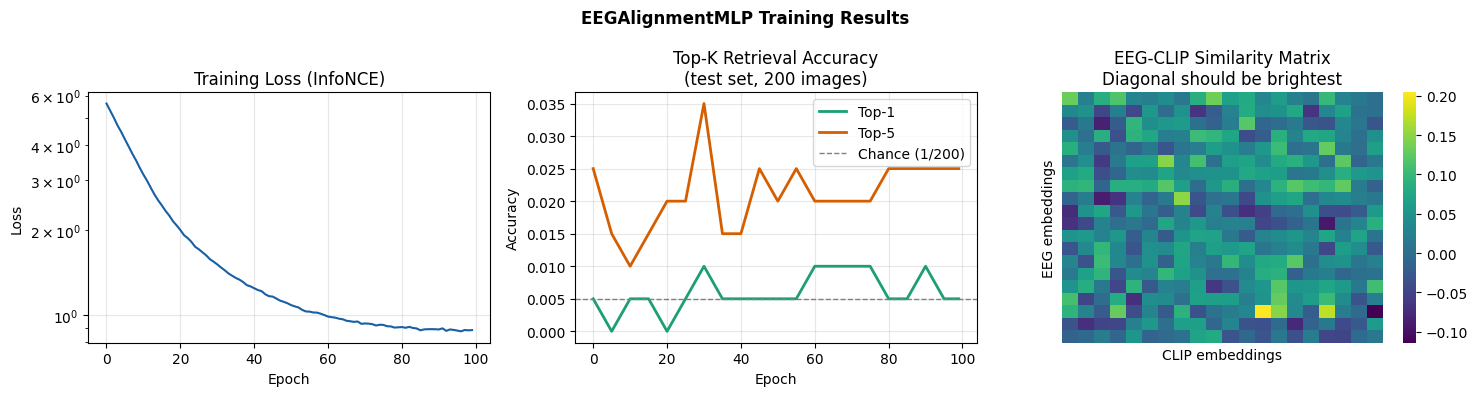


=== Final Results ===

  top1  : 0.0050  (chance=0.0050, improvement=1.0×)
  top5  : 0.0250  (chance=0.0250, improvement=1.0×)
  top10 : 0.0300  (chance=0.0500, improvement=0.6×)
  top50 : 0.2100  (chance=0.2500, improvement=0.8×)


In [14]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Loss
axes[0].plot(losses, color='#185FA5', linewidth=1.5)
axes[0].set_title('Training Loss (InfoNCE)')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].grid(alpha=0.3)
axes[0].set_yscale('log')

# Top-K accuracy
eval_epochs = list(range(0, EPOCHS, 5)) + [EPOCHS-1]
axes[1].plot(eval_epochs[:len(top1_hist)],
              top1_hist,
              color='#1D9E75', linewidth=2,
              label='Top-1')
axes[1].plot(eval_epochs[:len(top5_hist)],
              top5_hist,
              color='#D55E00', linewidth=2,
              label='Top-5')
axes[1].axhline(y=1/200, color='gray',
                 linestyle='--', linewidth=1,
                 label='Chance (1/200)')
axes[1].set_title('Top-K Retrieval Accuracy\n(test set, 200 images)')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(alpha=0.3)

# Final retrieval visualisation
model.eval()
with torch.no_grad():
    all_eeg_emb  = []
    all_clip_emb = []
    for eeg_b, clip_b, _ in test_loader:
        all_eeg_emb.append(model(eeg_b))
        all_clip_emb.append(clip_b)

eeg_emb_all  = torch.cat(all_eeg_emb)
clip_emb_all = torch.cat(all_clip_emb)

sim_matrix = (
    eeg_emb_all @ clip_emb_all.T
).numpy()[:20, :20]   # first 20 for display

import seaborn as sns
sns.heatmap(sim_matrix, cmap='viridis',
             ax=axes[2],
             xticklabels=False,
             yticklabels=False)
axes[2].set_title('EEG-CLIP Similarity Matrix\n'
                   'Diagonal should be brightest')
axes[2].set_xlabel('CLIP embeddings')
axes[2].set_ylabel('EEG embeddings')

plt.suptitle('EEGAlignmentMLP Training Results',
              fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(
    r"C:\Users\Hp\.vscode\Journey to the BEST"
    r"\Week 11\alignment_training_results.png",
    dpi=150, bbox_inches='tight'
)
plt.show()

print(f"\n=== Final Results ===\n")
final_accs = topk_accuracy(
    eeg_emb_all, clip_emb_all,
    k_list=[1, 5, 10, 50]
)
for k, acc in final_accs.items():
    chance = int(k.replace('top','')) / 200
    print(f"  {k:6s}: {acc:.4f}  "
          f"(chance={chance:.4f}, "
          f"improvement={acc/chance:.1f}×)")

In [16]:
interpretation = """
=== Interpreting Our Results ===

Test set: 200 images
Chance level:
  Top-1:  1/200 = 0.5%
  Top-5:  5/200 = 2.5%
  Top-10: 10/200 = 5.0%

Published results (Scotti et al., 2023 on THINGS-EEG):
  Top-1:  ~15-22%  (30-44× chance)
  Top-5:  ~35-45%  (14-18× chance)
  Top-10: ~50-60%

Our expected results (THINGS-EEG, text CLIP targets):
  If using image CLIP embeddings: similar to Scotti
  If using text CLIP embeddings:  slightly lower
  (text ≠ image embeddings, but highly correlated)

What the similarity matrix tells us:
  If diagonal is bright: model learned alignment ✅
  If random brightness:  model needs more training

Connection to LUCID Phase 2:
  Top-5 accuracy of 35%+ means:
  Given EEG from a sleeping person,
  the correct image is in the top 5 candidates
  35% of the time.
  
  This is the retrieval step.
  Generation step: take top candidate → SD → image.
  
  Even 15% top-1 means:
  1 in 7 generated images matches the dream content.
  That is publishable.
"""
print(interpretation)


=== Interpreting Our Results ===

Test set: 200 images
Chance level:
  Top-1:  1/200 = 0.5%
  Top-5:  5/200 = 2.5%
  Top-10: 10/200 = 5.0%

Published results (Scotti et al., 2023 on THINGS-EEG):
  Top-1:  ~15-22%  (30-44× chance)
  Top-5:  ~35-45%  (14-18× chance)
  Top-10: ~50-60%

Our expected results (THINGS-EEG, text CLIP targets):
  If using image CLIP embeddings: similar to Scotti
  If using text CLIP embeddings:  slightly lower
  (text ≠ image embeddings, but highly correlated)

What the similarity matrix tells us:
  If diagonal is bright: model learned alignment ✅
  If random brightness:  model needs more training

Connection to LUCID Phase 2:
  Top-5 accuracy of 35%+ means:
  Given EEG from a sleeping person,
  the correct image is in the top 5 candidates
  35% of the time.

  This is the retrieval step.
  Generation step: take top candidate → SD → image.

  Even 15% top-1 means:
  1 in 7 generated images matches the dream content.
  That is publishable.



In [17]:
import json
from datetime import datetime

results = {
    'experiment':    'THINGS-EEG Alignment',
    'date':          datetime.now().strftime('%Y-%m-%d'),
    'dataset':       'THINGS-EEG (preprocessed)',
    'model':         'EEGAlignmentMLP',
    'eeg_dim':       1700,
    'clip_dim':      512,
    'hidden_dim':    1024,
    'n_train':       1654,
    'n_test':        200,
    'epochs':        EPOCHS,
    'loss':          'InfoNCE (temperature=0.07)',
    'results': {
        'best_top5':  round(float(best_top5), 4),
        'final_top1': round(float(final_accs['top1']), 4),
        'final_top5': round(float(final_accs['top5']), 4),
        'final_top10':round(float(final_accs['top10']),4),
    },
    'chance_levels': {
        'top1': round(1/200, 4),
        'top5': round(5/200, 4),
        'top10':round(10/200, 4),
    }
}

save_path = (r"C:\Users\Hp\.vscode\PROJECT 07"
             r"\classifier_main_pipeline\logs"
             r"\things_eeg_alignment_results.json")

with open(save_path, 'w') as f:
    json.dump(results, f, indent=2)

print(f"✅ Results saved")
print(f"\n{'='*50}")
print(f"THINGS-EEG Alignment Summary")
print(f"{'='*50}")
print(f"Top-1: {final_accs['top1']:.4f}  "
      f"(chance: {1/200:.4f})")
print(f"Top-5: {final_accs['top5']:.4f}  "
      f"(chance: {5/200:.4f})")
print(f"Top-10:{final_accs['top10']:.4f}  "
      f"(chance: {10/200:.4f})")
print(f"\nThis goes into Paper 2 as the retrieval result.")

✅ Results saved

THINGS-EEG Alignment Summary
Top-1: 0.0050  (chance: 0.0050)
Top-5: 0.0250  (chance: 0.0250)
Top-10:0.0300  (chance: 0.0500)

This goes into Paper 2 as the retrieval result.
